In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.signal import fftconvolve


### View the xcorr response map of a scaled unit circle

- define the circle image parameters
- generate the circular aperture function
- make the time series of the circle moving
  - linearly in one direction
  - 1 pixel/frame movement speed

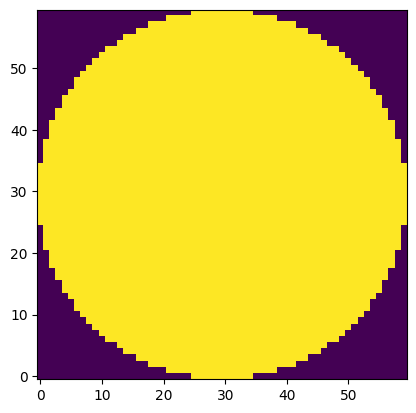

In [8]:
image_size = 60
circle_radius = 30
blank_image = np.zeros((image_size, image_size))
image_center = (image_size - 1) / 2

x_arr = np.arange(stop=image_size, dtype=float)[None,:] - image_center
y_arr = np.arange(stop=image_size, dtype=float)[:,None] - image_center

rho2d = np.sqrt(x_arr**2 + y_arr**2)

circle_image = blank_image.copy()
circle_image[rho2d <= circle_radius] = 1

plt.imshow(circle_image, origin="lower")



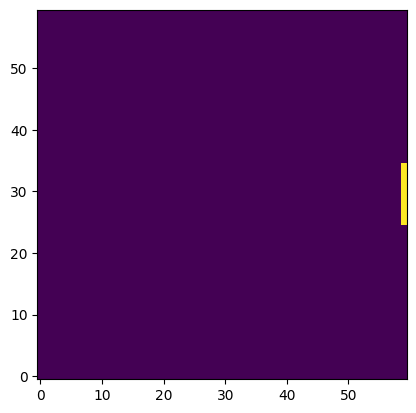

In [71]:
# Make the circle move
circle_image_series = np.zeros((circle_radius*2,image_size, image_size))

for i in range(circle_radius*2):
    moving_rho2d = np.sqrt((x_arr - i)**2 + y_arr**2)
    moving_circle = blank_image.copy()
    moving_circle[moving_rho2d <= circle_radius] = 1
    circle_image_series[i,:,:] = moving_circle
    

plt.imshow(circle_image_series[59,:,:], origin="lower")

## Do the cross-correlation and view the response map
- Do the FT transform of the entire moving circle array
- Need to figure out the zero padding
- Multiply in the Fourier domain
- Inverse transform all at once for efficiency

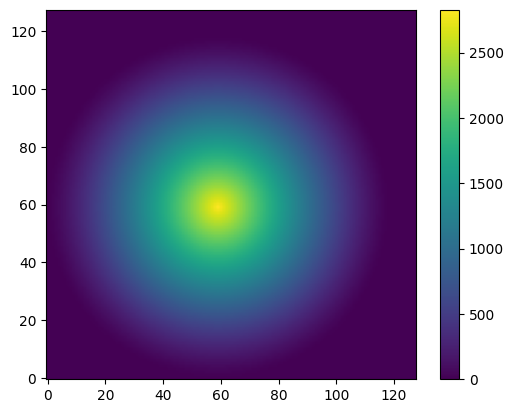

In [186]:
# compute the 2D FFTs

# do the zero-padding
pad_size = max(128, image_size * 2  - 1)
padded_circle_image_series = np.pad(
    array=circle_image_series,
    pad_width=((0,0),(pad_size,pad_size), (pad_size,pad_size)))

# plt.imshow(padded_circle_image_series[0,:,:], origin="lower")

moving_circle_all_ft = np.fft.rfft2(
    circle_image_series,
    s=(pad_size,pad_size),
    # axes=(1,2),
    )
# plt.imshow(moving_circle_all_ft.real[10,:,:], origin="lower")
# print(moving_circle_all_ft.shape)
circle_image_ft = moving_circle_all_ft[0,:,:].copy()
circle_image_ft_conj = np.conj(circle_image_ft)

# do the CC in the Fourier domain


moving_circle_all_cc = np.multiply(circle_image_ft, moving_circle_all_ft)
moving_circle_all_cc_ifft = np.fft.irfft2(
    moving_circle_all_cc,
    # s=(pad_size,pad_size),
    )
moving_circle_all_cc_ifft_shifted = np.fft.fftshift(moving_circle_all_cc_ifft)

plt.imshow(moving_circle_all_cc_ifft[0,:,:], origin="lower")
plt.colorbar()



(60, 119, 119)


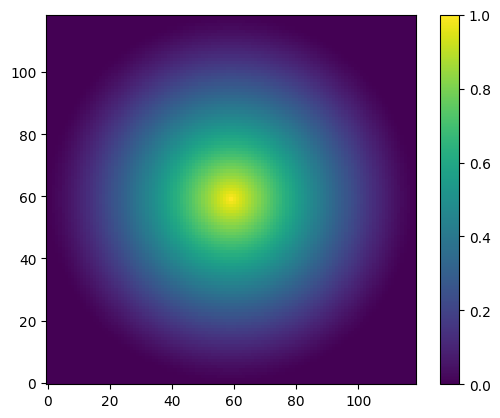

In [166]:
# Try using the fftconvolve function
output_shape = (2*image_size - 1, 2*image_size - 1)
convolved_circle_series = np.zeros((circle_radius*2, *output_shape))
print(convolved_circle_series.shape)
for i in range(circle_radius*2):
    result_fftconvolve = fftconvolve(
        circle_image_series[i,:,:],
        circle_image_series[0,:,:],
        mode="full")
    convolved_circle_series[i,:,:] = result_fftconvolve

normalized_cc_circle_series = convolved_circle_series / np.max(convolved_circle_series)
plt.imshow(normalized_cc_circle_series[0,:,:], origin="lower")
plt.colorbar()


### View the series of pixel values of the CC response cube

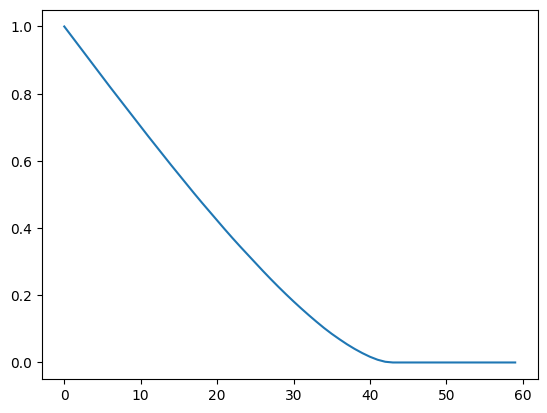

In [164]:
cc_frame_size = normalized_cc_circle_series.shape[1]
cc_map_center = cc_frame_size // 2
circle_cc_series = np.zeros(circle_radius*2)
for i in range(circle_radius*2):
    circle_cc_series[i] = normalized_cc_circle_series[i, cc_map_center + i, cc_map_center]

plt.plot(circle_cc_series)
